<a href="https://colab.research.google.com/github/yunayana/Sztuczna_Inteligancja_STAC_2026/blob/main/Lab2_Model_liniowy_cd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [5]:
training_data = np.load("TF_dataset.npz")
input_size = 2
output_size = 1

In [22]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation='sigmoid', input_shape=(input_size,)),
    tf.keras.layers.Dense(output_size)
])

model.compile(optimizer='sgd', loss='mean_absolute_error') #SGD + MAE
model.fit(training_data['inputs'], training_data['targets'], epochs=100, verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 70.3839   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 70.1747  
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 69.9751 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 69.7701 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 69.5485 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 69.3312 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 69.1261
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 68.9153
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 68.6866
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 68.4350
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 68.1499 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 67.8502 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 67.5610 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 67.2745 
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [23]:
model.layers[0].get_weights()

[array([[-1.6838558 ,  1.3742002 , -1.4526447 , -1.5999181 , -1.2159235 ],
        [-0.57573414,  0.90099514, -0.61843246, -1.1617135 , -0.6502145 ]],
       dtype=float32),
 array([-0.4723511 ,  0.70632404, -0.5418778 , -0.75812113, -0.7952692 ],
       dtype=float32)]

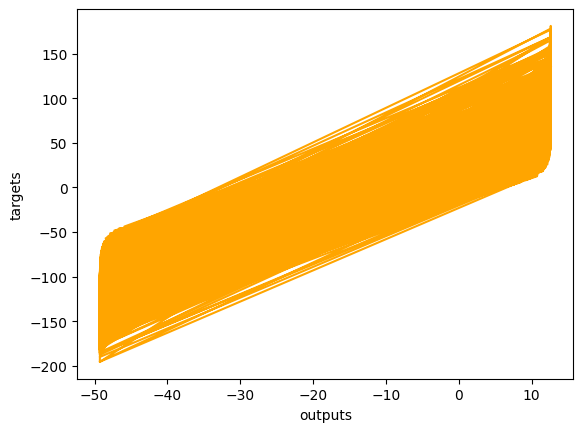

In [24]:
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])),
          np.squeeze(training_data['targets']), color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show() #dodanie warstwy ukrytej z 5 neuronami i aktywacją sigmoidalną przy optimizerze SGD i stracie MAE spowodowało, że model stał się nieliniowy: predykcje tworzą rosnący, ale wyraźnie wygięty pas punktów, co pokazuje odejście od idealnie liniowej zależności.